# Intro

This notebook is used to investigate, visualize and analyze the hyperparameters search results for the models described in this study.


# Lib imports

In [4]:
import warnings
from copy import deepcopy
from pathlib import Path

import autoroot
import autorootcwd
import joblib
import matplotlib.pyplot as plt
import optuna as opt
import pingouin as pg
import seaborn as sns
import plotly as py
import torch_geometric as pyg
from IPython.display import Markdown, display

import aml_magic.src.consts as cc
import aml_magic.src.models.magic as magic
import aml_magic.src.stages.hp_tune as hp_tune
import aml_magic.src.utils.results_summary_utils as rsu

warnings.filterwarnings("ignore")

# Convolution model complexity check

In [5]:
model_variants = ["amlsim_31", "amlsim_51", "amlsim_101", "amlsim_201"]
for variant in model_variants:
    configs = hp_tune.prepare_configs(variant)
    data = hp_tune.prepare_data_for_dataset(configs)
    arch = configs.training_configs.get_achitecture_for_dataset(variant)
    model = magic.MAGICPl(**arch.model_dump())
    total_params = sum(p.numel() for p in model.magic_linkpred.magic.parameters())
    print(f"Variant: {variant}, total params: {total_params}")
    print("Model structure")
    print(
        pyg.nn.summary(
            model.magic_linkpred,
            data.train_dataset[0].x,
            data.train_dataset[0].edge_index,
            data.train_dataset[0].edge_attr,
        )
    )
    print("\n\n")

Variant: amlsim_31, total params: 2426
Model structure
+--------------------------+--------------------------+-----------------+----------+
| Layer                    | Input Shape              | Output Shape    | #Param   |
|--------------------------+--------------------------+-----------------+----------|
| MAGIC_LinkPredictor      | [16, 6], [2, 8], [8, 8]  | [8, 32], [8, 2] | 3,324    |
| ├─(magic)MAGICModel      | [16, 6], [2, 8], [8, 8]  | [16, 16]        | 2,426    |
| │    └─(convs)ModuleList | --                       | --              | 2,426    |
| │    │    └─(0)MAGICConv | [16, 6], [2, 8], [8, 8]  | [16, 16]        | 536      |
| │    │    └─(1)MAGICConv | [16, 16], [2, 8], [8, 8] | [16, 16]        | 946      |
| │    │    └─(2)MAGICConv | [16, 16], [2, 8], [8, 8] | [16, 16]        | 946      |
| ├─(mlp)Sequential        | [8, 32]                  | [8, 2]          | 898      |
| │    └─(0)BatchNorm1d    | [8, 32]                  | [8, 32]         | 64       |
| │    └─(

# Hyperparameters search results

## AMLSim 1/3

In [6]:
study_amlsim_31 = rsu.load_study("amlsim_31")

In [7]:
from importlib import reload

rsu = reload(rsu)

### AMLSim 1/3 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_n_convs,state
0,0,0.584421,0.618611,128.0,2025-01-02 13:40:24.733968,2025-01-02 13:40:35.916049,0 days 00:00:11.182081,('softmax'),mean,64,2,COMPLETE
1,1,0.918238,0.904437,384.0,2025-01-02 13:40:35.916589,2025-01-02 13:40:48.562523,0 days 00:00:12.645934,"('add', 'min', 'max')",mean,64,6,COMPLETE
2,2,0.948683,0.936090,192.0,2025-01-02 13:40:48.562910,2025-01-02 13:40:57.592487,0 days 00:00:09.029577,"('add', 'min', 'max')",concat,64,3,COMPLETE


#### Feature importances

{'gnn_sizes': 0.014581865292893865,
 'aggr': 0.013723203578176794,
 'n_convs': 0.003990100271606364,
 'embed_reduction_mode': 0.0031820079059079287}

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 8
  warnings.warn('covariance of constraints does not have full '
/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of

,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,0.0000,3.0,0.0000,2.307211e+16,0.0,1.0,Yes
1,No. Conv. Layers,-0.0000,3.0,-0.0000,-5.878126e+14,1.0,1.0,No
2,Aggr.,-0.0000,2.0,-0.0000,-2.218904e+13,1.0,1.0,No
3,Embed Reduction,0.0000,1.0,0.0000,2.356597e+15,0.0,1.0,Yes
4,Conv. Dim. * No. Conv. Layers,0.0000,9.0,0.0000,4.874483e+15,0.0,1.0,Yes
5,Conv. Dim. * Aggr.,0.0000,6.0,0.0000,2.068190e+16,0.0,1.0,Yes
6,No. Conv. Layers * Aggr.,-0.0000,6.0,-0.0000,-1.568045e+16,1.0,1.0,No
7,Conv. Dim. * Embed Reduction,0.0000,3.0,0.0000,1.148977e+14,0.0,1.0,Yes
8,No. Conv. Layers * Embed Reduction,0.0000,3.0,0.0000,3.164461e+14,0.0,1.0,Yes
9,Aggr. * Embed Reduction,-0.0000,2.0,-0.0000,-1.024366e+14,1.0,1.0,No


#### Plots

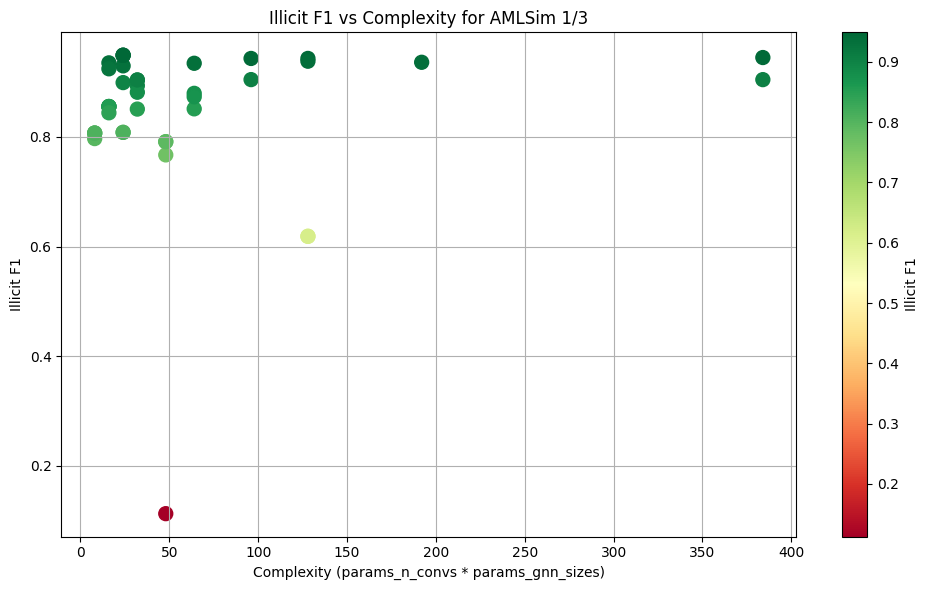

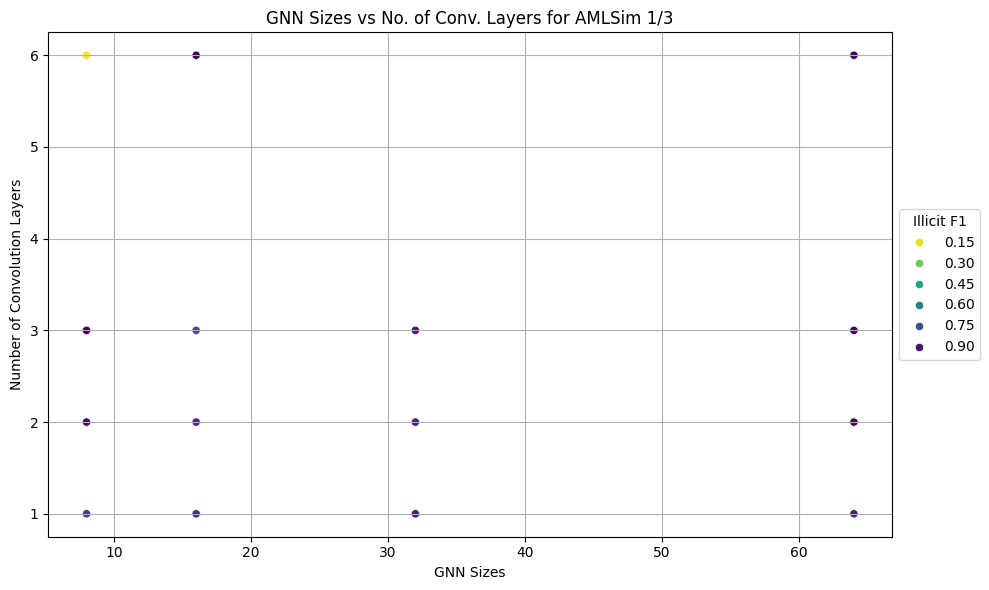

In [8]:
rsu.build_and_save_study_analysis(study_amlsim_31, "AMLSim 1/3")

## AMLSim 1/5

### AMLSim 1/5 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_n_convs,state
0,0,0.932618,0.902564,128.0,2025-01-02 13:45:26.454588,2025-01-02 13:45:42.870593,0 days 00:00:16.416005,('softmax'),mean,64,2,COMPLETE
1,1,0.920499,0.879845,384.0,2025-01-02 13:45:42.870810,2025-01-02 13:46:09.438081,0 days 00:00:26.567271,"('add', 'min', 'max')",mean,64,6,COMPLETE
2,2,0.907234,0.855932,192.0,2025-01-02 13:46:09.438368,2025-01-02 13:46:26.792535,0 days 00:00:17.354167,"('add', 'min', 'max')",concat,64,3,COMPLETE


#### Feature importances

{'n_convs': 0.03186677038564741,
 'aggr': 0.012556129079150949,
 'gnn_sizes': 0.01191196373994019,
 'embed_reduction_mode': 0.00916981233178282}

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 18, but rank is 7

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 6, but rank is 3

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 6, but rank is 3



,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,0.0000,3.0,0.0000,8.116751e+13,0.0,1.0,Yes
1,No. Conv. Layers,-0.0000,3.0,-0.0000,-1.586322e+16,1.0,1.0,No
2,Aggr.,0.0000,2.0,0.0000,2.935183e+15,0.0,1.0,Yes
3,Embed Reduction,0.0000,1.0,0.0000,5.420861e+14,0.0,1.0,Yes
4,Conv. Dim. * No. Conv. Layers,-0.0000,9.0,-0.0000,-1.517755e+16,1.0,1.0,No
5,Conv. Dim. * Aggr.,0.0000,6.0,0.0000,1.677411e+15,0.0,1.0,Yes
6,No. Conv. Layers * Aggr.,-0.0000,6.0,-0.0000,-6.834938e+15,1.0,1.0,No
7,Conv. Dim. * Embed Reduction,0.0000,3.0,0.0000,3.204844e+15,0.0,1.0,Yes
8,No. Conv. Layers * Embed Reduction,-0.0000,3.0,-0.0000,-8.137630e+14,1.0,1.0,No
9,Aggr. * Embed Reduction,0.0000,2.0,0.0000,1.059066e+16,0.0,1.0,Yes


#### Plots

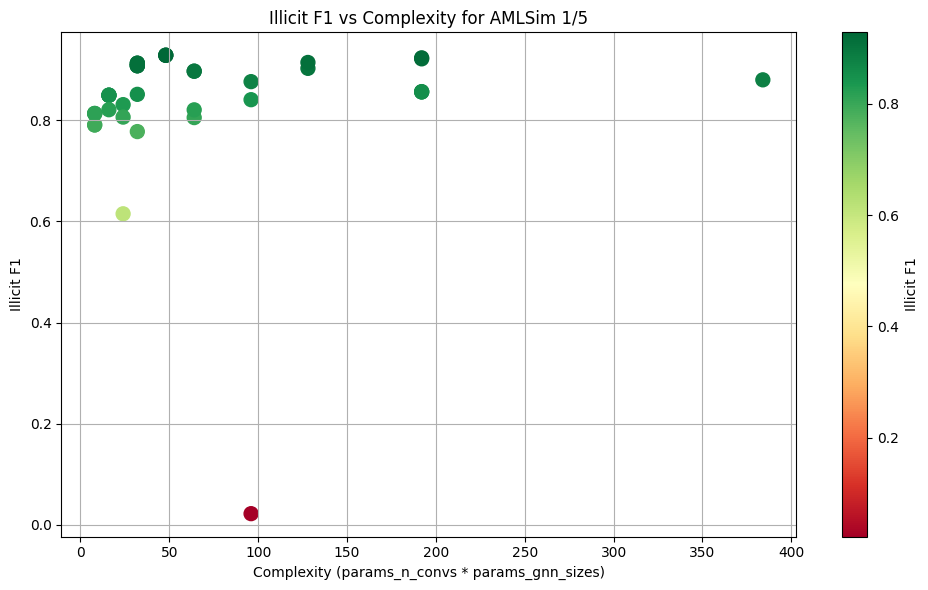

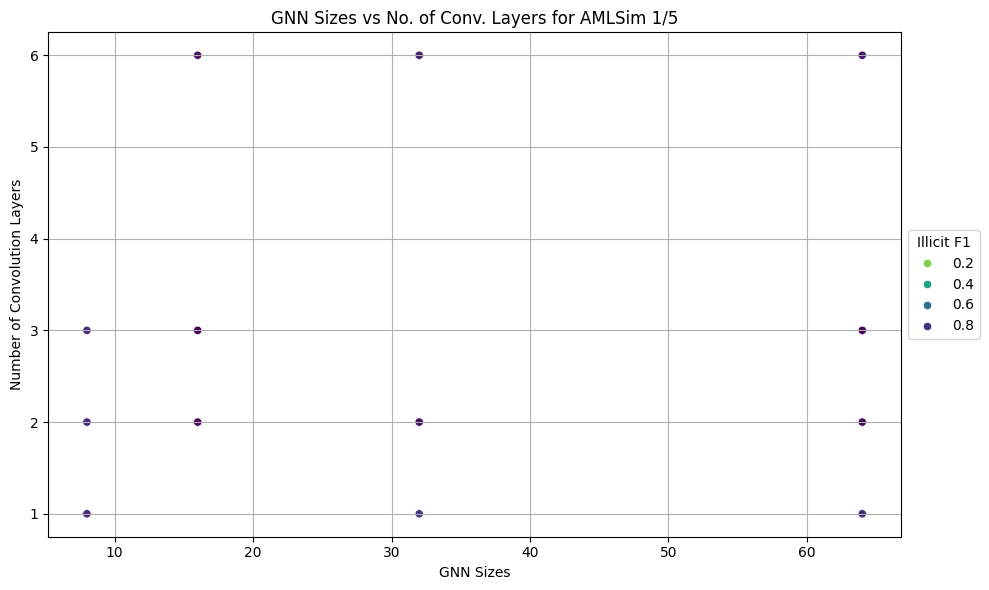

In [9]:
study_amlsim_51 = rsu.load_study("amlsim_51")
rsu.build_and_save_study_analysis(study_amlsim_51, "AMLSim 1/5")

## AMLSim 1/10

### AMLSim 1/10 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_n_convs,state
0,0,0.878029,0.781250,128.0,2025-01-02 13:55:54.509233,2025-01-02 13:56:11.517685,0 days 00:00:17.008452,('softmax'),mean,64,2,COMPLETE
1,1,0.876881,0.780384,384.0,2025-01-02 13:56:11.518026,2025-01-02 13:56:39.268511,0 days 00:00:27.750485,"('add', 'min', 'max')",mean,64,6,COMPLETE
2,2,0.637499,0.356557,192.0,2025-01-02 13:56:39.268741,2025-01-02 13:56:50.162082,0 days 00:00:10.893341,"('add', 'min', 'max')",concat,64,3,COMPLETE


#### Feature importances

{'embed_reduction_mode': 0.052476252439693206,
 'n_convs': 0.0296304246899896,
 'aggr': 0.011805502059364485,
 'gnn_sizes': 0.009527693535354296}

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 18, but rank is 7

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 9, but rank is 3

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 6, but rank is 3

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 6, but rank is 3



,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,0.0000,3.0,0.0000,2.984774e+15,0.0,1.0,Yes
1,No. Conv. Layers,0.0000,3.0,0.0000,1.516546e+15,0.0,1.0,Yes
2,Aggr.,-0.0000,2.0,-0.0000,-3.344830e+15,1.0,1.0,No
3,Embed Reduction,-0.0000,1.0,-0.0000,-4.510182e+15,1.0,1.0,No
4,Conv. Dim. * No. Conv. Layers,0.0000,9.0,0.0000,1.726374e+15,0.0,1.0,Yes
5,Conv. Dim. * Aggr.,-0.0000,6.0,-0.0000,-7.623298e+16,1.0,1.0,No
6,No. Conv. Layers * Aggr.,-0.0000,6.0,-0.0000,-2.001411e+15,1.0,1.0,No
7,Conv. Dim. * Embed Reduction,0.0000,3.0,0.0000,5.753597e+16,0.0,1.0,Yes
8,No. Conv. Layers * Embed Reduction,0.0000,3.0,0.0000,2.142533e+13,0.0,1.0,Yes
9,Aggr. * Embed Reduction,0.0000,2.0,0.0000,2.638333e+15,0.0,1.0,Yes


#### Plots

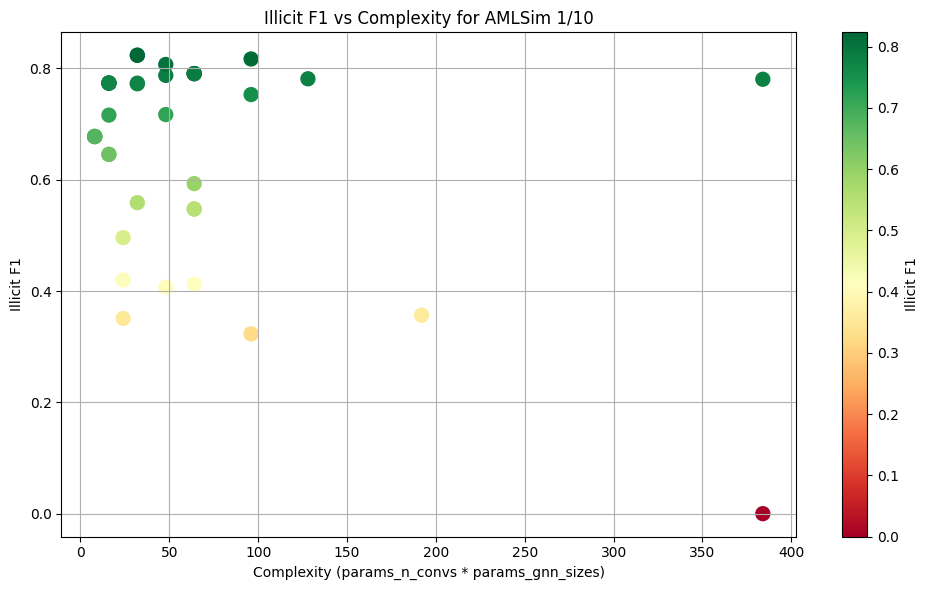

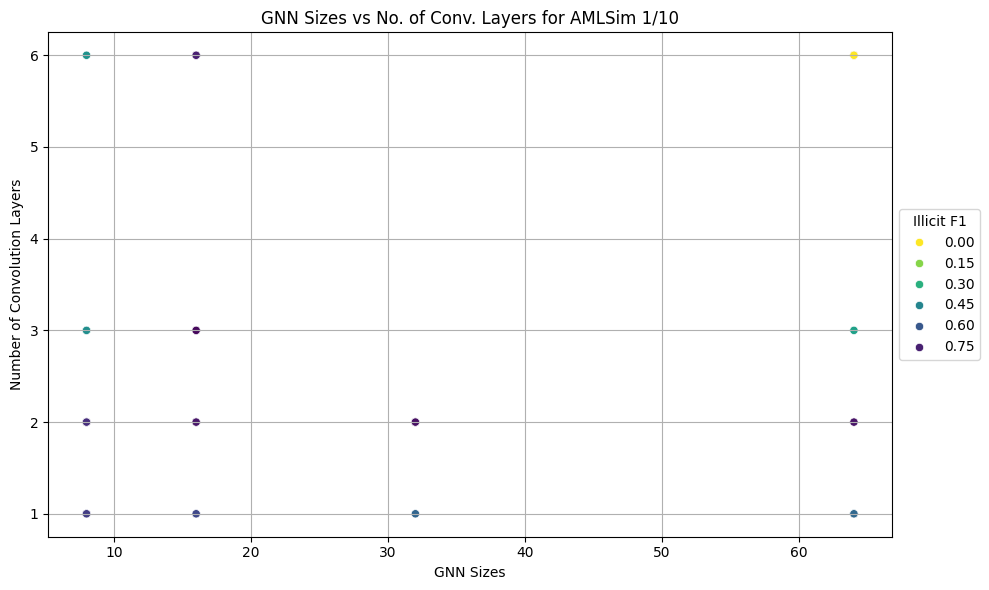

In [10]:
study_amlsim_110 = rsu.load_study("amlsim_101")
rsu.build_and_save_study_analysis(study_amlsim_110, "AMLSim 1/10")

## AMLSim 1/20

In [11]:
study_amlsim_120 = rsu.load_study("amlsim_201")

### AMLSim 1/20 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_n_convs,state
0,0,0.872253,0.758170,128.0,2025-01-02 14:06:49.484310,2025-01-02 14:07:05.379381,0 days 00:00:15.895071,('softmax'),mean,64,2,COMPLETE
1,1,0.911599,0.833333,384.0,2025-01-02 14:07:05.379659,2025-01-02 14:07:40.127747,0 days 00:00:34.748088,"('add', 'min', 'max')",mean,64,6,COMPLETE
2,2,0.889366,0.793867,192.0,2025-01-02 14:07:40.128065,2025-01-02 14:08:03.570274,0 days 00:00:23.442209,"('add', 'min', 'max')",concat,64,3,COMPLETE


#### Feature importances

{'aggr': 0.019955818127332155,
 'n_convs': 0.00962289248045372,
 'embed_reduction_mode': 0.002910299337875224,
 'gnn_sizes': 0.0005572303223147585}

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 18, but rank is 8

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 9, but rank is 4

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5

/home/filip/miniconda3/envs/aml_magic/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not ha

,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,-0.0000,3.0,-0.0000,-1.982969e+16,1.0,1.0,No
1,No. Conv. Layers,-0.0000,3.0,-0.0000,-1.340822e+15,1.0,1.0,No
2,Aggr.,0.0000,2.0,0.0000,3.633347e+15,0.0,1.0,Yes
3,Embed Reduction,0.0000,1.0,0.0000,1.971335e+14,0.0,1.0,Yes
4,Conv. Dim. * No. Conv. Layers,-0.0000,9.0,-0.0000,-4.504574e+15,1.0,1.0,No
5,Conv. Dim. * Aggr.,-0.0000,6.0,-0.0000,-2.784319e+15,1.0,1.0,No
6,No. Conv. Layers * Aggr.,-0.0000,6.0,-0.0000,-7.611905e+15,1.0,1.0,No
7,Conv. Dim. * Embed Reduction,-0.0000,3.0,-0.0000,-2.704101e+14,1.0,1.0,No
8,No. Conv. Layers * Embed Reduction,-0.0000,3.0,-0.0000,-1.397190e+15,1.0,1.0,No
9,Aggr. * Embed Reduction,0.0000,2.0,0.0000,1.871991e+13,0.0,1.0,Yes


#### Plots

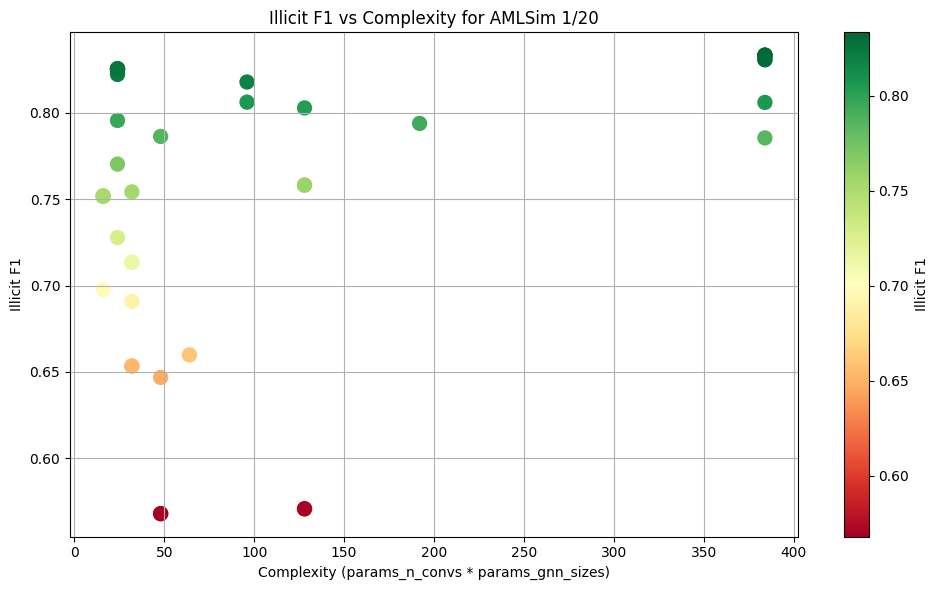

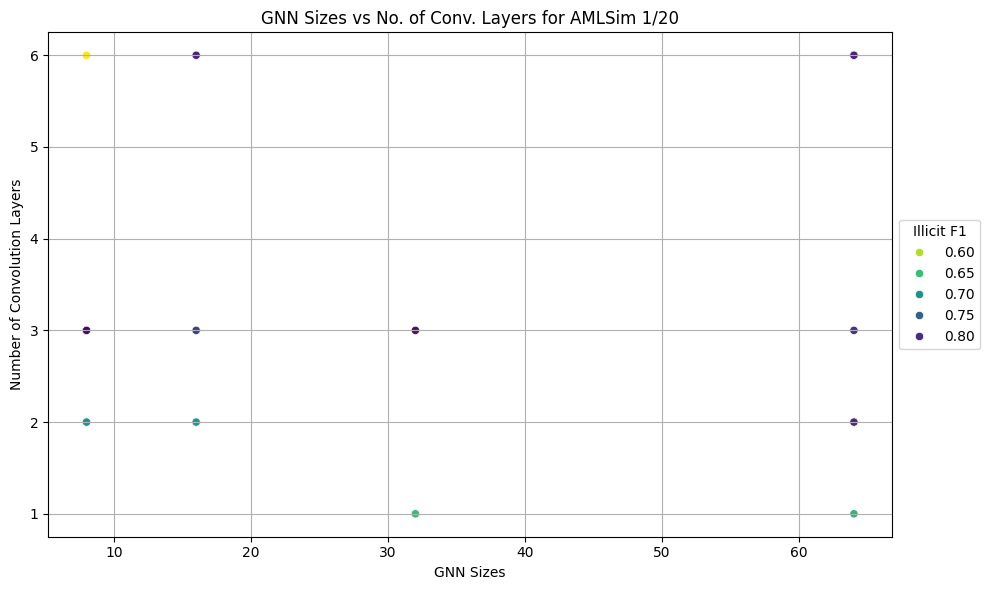

In [12]:
rsu.build_and_save_study_analysis(study_amlsim_120, "AMLSim 1/20")